In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df_original = pd.read_csv('dados.csv')

In [77]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 15 columns):
 #   Column                                                         Non-Null Count  Dtype
---  ------                                                         --------------  -----
 0   Carimbo de data/hora                                           48 non-null     str  
 1   Região onde mora:                                              48 non-null     str  
 2   Gênero:                                                        48 non-null     str  
 3   Escolaridade:                                                  48 non-null     str  
 4   A formação é na área de tecnologia?                            48 non-null     str  
 5   Tempo de atuação na área de tecnologia:                        48 non-null     str  
 6   Área de atuação que mais se adequa para sua realidade:         48 non-null     str  
 7   Cargo que mais se adequa para a sua realidade:                 48 non-null     str  
 8   Sen

In [78]:
df = df_original.copy()

In [79]:
df.columns = [
    "data_hora",
    "regiao",
    "genero",
    "escolaridade",
    "formacao_tecnologia",
    "tempo_tecnologia",
    "area_atuacao",
    "cargo",
    "senioridade",
    "faixa_salarial",
    "modalidade_trabalho",
    "modalidade_atuacao",
    "segmento_empresa",
    "perfil_empresa",
    "satisfacao_mercado",
]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   data_hora            48 non-null     str  
 1   regiao               48 non-null     str  
 2   genero               48 non-null     str  
 3   escolaridade         48 non-null     str  
 4   formacao_tecnologia  48 non-null     str  
 5   tempo_tecnologia     48 non-null     str  
 6   area_atuacao         48 non-null     str  
 7   cargo                48 non-null     str  
 8   senioridade          48 non-null     str  
 9   faixa_salarial       48 non-null     str  
 10  modalidade_trabalho  48 non-null     str  
 11  modalidade_atuacao   48 non-null     str  
 12  segmento_empresa     48 non-null     str  
 13  perfil_empresa       48 non-null     str  
 14  satisfacao_mercado   48 non-null     int64
dtypes: int64(1), str(14)
memory usage: 5.8 KB


In [80]:
df = df.drop(columns=["data_hora"])

In [81]:
for coluna in df.columns:
    print(coluna)
    print(df[coluna].value_counts())

regiao
regiao
Sul               42
Sudeste            3
Centro-Oeste       1
Fora do Brasil     1
Norte              1
Name: count, dtype: int64
genero
genero
Masculino cis     41
Feminino cis       6
Feminino trans     1
Name: count, dtype: int64
escolaridade
escolaridade
Pós-graduado           20
Superior completo      13
Superior incompleto     8
Mestre                  6
Doutor/Pós-doutor       1
Name: count, dtype: int64
formacao_tecnologia
formacao_tecnologia
Sim    42
Não     6
Name: count, dtype: int64
tempo_tecnologia
tempo_tecnologia
mais que 10 anos    25
6 a 10 anos          9
0 a 2 anos           8
3 a 5 anos           6
Name: count, dtype: int64
area_atuacao
area_atuacao
Desenvolvimento de Software      29
Infraestrutura                    5
Ciência de Dados/BI/IA            5
Outros                            5
Teste e Qualidade de Software     2
Cybersegurança                    2
Name: count, dtype: int64
cargo
cargo
Desenvolvedor/Analista/Operacional    31
Liderança T

In [82]:
mapa_salario = {
    'até 2 mil reais' : '< R$ 2k',
    'entre 2 mil a 5 mil reais': 'R$ 2k - 5k',
    'entre 5 mil a 8 mil reais': 'R$ 5k - 8k',
    'entre 8 mil a 15 mil reais': 'R$ 8k - 15k',
    'mais que 15 mil reais': '> R$ 15k',
    'Variável' : 'variável'
}
df['faixa_salarial'] = df['faixa_salarial'].map(mapa_salario)

ordem_salario = [
    '< R$ 2k',
    'R$ 2k - 5k',
    'R$ 5k - 8k',
    'R$ 8k - 15k',
    '> R$ 15k',
    'variável'
]
df['faixa_salarial'] = pd.Categorical(df['faixa_salarial'], categories=ordem_salario, ordered=True)

In [83]:
print(df['faixa_salarial'].value_counts(sort=False))

faixa_salarial
< R$ 2k         2
R$ 2k - 5k      9
R$ 5k - 8k      7
R$ 8k - 15k    15
> R$ 15k       13
variável        2
Name: count, dtype: int64


In [84]:
mapa_segmento = {
    'Empresa que não é do ramo mas tem setor de tecnologia' : 'Não-Tech (Setor TI)',
    'Empresa de tecnologia que oferta produtos (Ex: SaaS)' : 'Tech (SaaS / Produtos)',
    'Empresa de tecnologia que oferta serviços (Ex: Consultoria)' : 'Tech (Consultoria / Serviços)',
    'Outro': 'outro'
}
df['segmento_empresa'] = df['segmento_empresa'].map(mapa_segmento)

In [85]:
df['segmento_empresa'].value_counts()

segmento_empresa
Não-Tech (Setor TI)              17
Tech (SaaS / Produtos)           15
Tech (Consultoria / Serviços)    15
outro                             1
Name: count, dtype: int64

In [86]:
mapa_trabalho = {
    'CLT' : 'CLT',
    'PJ' : 'PJ',
    'Autônomo/Horista/Prestador de serviço' : 'Autônomo/Prestador',
    'Estágio/Bolsa': 'Estágio/Bolsa'
}
df['modalidade_trabalho'] = df['modalidade_trabalho'].map(mapa_trabalho)

In [87]:
df['modalidade_trabalho'].value_counts()

modalidade_trabalho
CLT                   31
PJ                    12
Autônomo/Prestador     3
Estágio/Bolsa          2
Name: count, dtype: int64

In [88]:
ordem_senioridade = [
    'Estagiário/Trainee',
    'Júnior',
    'Pleno',
    'Sênior',
    'Especialista',
    'Não se aplica'
]
df['senioridade'] = pd.Categorical(df['senioridade'], categories=ordem_senioridade, ordered=True)

In [89]:
df['senioridade'].value_counts(sort=False)

senioridade
Estagiário/Trainee     2
Júnior                 5
Pleno                 11
Sênior                18
Especialista          11
Não se aplica          1
Name: count, dtype: int64

In [90]:
ordem_escolaridade = [
    'Superior incompleto',
    'Superior completo',
    'Pós-graduado',
    'Mestre',
    'Doutor/Pós-doutor',
]
df['escolaridade'] = pd.Categorical(df['escolaridade'], categories=ordem_escolaridade, ordered=True)

In [91]:
df['escolaridade'].value_counts(sort=False)

escolaridade
Superior incompleto     8
Superior completo      13
Pós-graduado           20
Mestre                  6
Doutor/Pós-doutor       1
Name: count, dtype: int64

In [92]:
ordem_tempo_exp = [
    '0 a 2 anos',
    '3 a 5 anos',
    '6 a 10 anos',
    'mais que 10 anos'
]
df['tempo_tecnologia'] = pd.Categorical(df['tempo_tecnologia'], categories=ordem_tempo_exp, ordered=True)

In [93]:
df['tempo_tecnologia'].value_counts(sort=False)

tempo_tecnologia
0 a 2 anos           8
3 a 5 anos           6
6 a 10 anos          9
mais que 10 anos    25
Name: count, dtype: int64

In [94]:
mapa_perfil_empresa = {
    'Nacional' : 'Nacional',
    'Multinacional Brasileira - Alocado em time nacional' : 'Multinacional BR (Time BR)',
    'Multinacional Estrangeira - Alocado em time nacional' : 'Multinacional Gringa (Time BR)',
    'Multinacional Brasileira - Alocado em time com estrangeiros' : 'Multinacional BR (Time Global)',
    'Multinacional Estrangeira - Alocado em time com estrangeiros' : 'Multinacional Gringa (Time Global)',
    'Não se aplica' : 'Não se aplica',
}
df['perfil_empresa'] = df['perfil_empresa'].map(mapa_perfil_empresa)

In [95]:
df['perfil_empresa'].value_counts()

perfil_empresa
Nacional                              26
Multinacional BR (Time BR)             5
Multinacional Gringa (Time BR)         5
Não se aplica                          4
Multinacional Gringa (Time Global)     4
Multinacional BR (Time Global)         4
Name: count, dtype: int64

In [96]:
tabela_senioridade_salario = pd.crosstab(
    df['senioridade'],
    df['faixa_salarial'],
    margins_name="Total"
)
print(tabela_senioridade_salario)

faixa_salarial      < R$ 2k  R$ 2k - 5k  R$ 5k - 8k  R$ 8k - 15k  > R$ 15k  \
senioridade                                                                  
Estagiário/Trainee        2           0           0            0         0   
Júnior                    0           5           0            0         0   
Pleno                     0           3           3            4         1   
Sênior                    0           1           3            8         5   
Especialista              0           0           1            2         7   
Não se aplica             0           0           0            1         0   

faixa_salarial      variável  
senioridade                   
Estagiário/Trainee         0  
Júnior                     0  
Pleno                      0  
Sênior                     1  
Especialista               1  
Não se aplica              0  


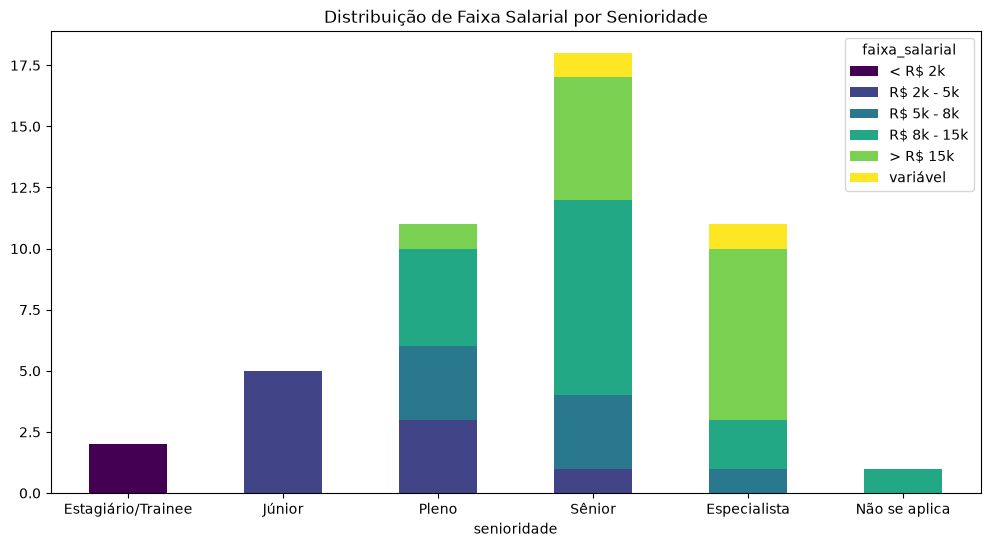

In [97]:
tabela_senioridade_salario.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))
plt.title('Distribuição de Faixa Salarial por Senioridade')
plt.xticks(rotation=0)
plt.show()

In [98]:
tabela_modalidade_salario = pd.crosstab(
    df['faixa_salarial'],
    df['modalidade_trabalho'],
    margins_name="Total"
)
print(tabela_modalidade_salario)

modalidade_trabalho  Autônomo/Prestador  CLT  Estágio/Bolsa  PJ
faixa_salarial                                                 
< R$ 2k                               0    0              2   0
R$ 2k - 5k                            1    4              0   4
R$ 5k - 8k                            0    7              0   0
R$ 8k - 15k                           0   12              0   3
> R$ 15k                              1    8              0   4
variável                              1    0              0   1


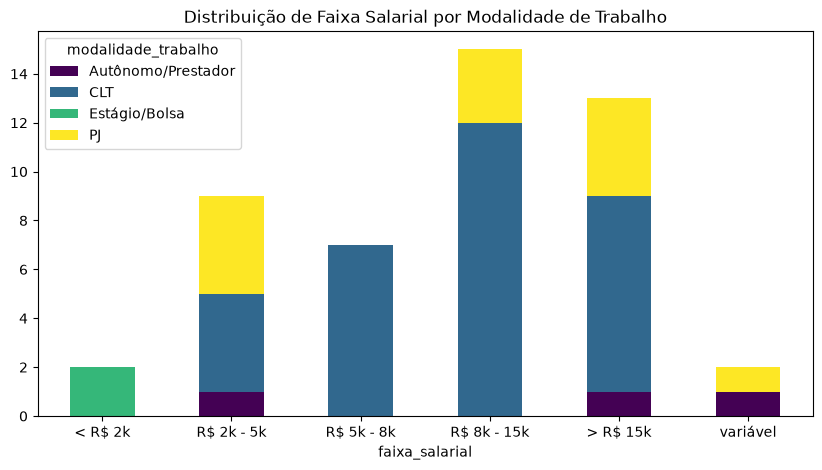

In [99]:
tabela_modalidade_salario.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 5))
plt.title('Distribuição de Faixa Salarial por Modalidade de Trabalho')
plt.xticks(rotation=0)
plt.show()